# DDPM on MNIST

Here, we want to implement and train a simple diffusion model on the MNIST data set, which learns to generate images of handwritten digits.

### Imports, loading the data and fundamental classes


In [2]:
import importlib.util
import sys
import subprocess

# Check if the package is available
if importlib.util.find_spec("torch_lr_finder") is None:
    print("torch_lr_finder not found. Installing...")
    # Install using the current python executable to ensure it hits the right environment
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-lr-finder"])
    print("Installation complete.")

In [3]:
from torch_lr_finder import LRFinder
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm

from torch.utils.data import DataLoader,Subset
from torchvision import datasets, transforms

batch_size = 32


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

c:\Users\elias\miniconda3\envs\ml-env\lib\site-packages\torch_lr_finder\lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cpu


This class sets the noise schedule beta_t

In [4]:
class NoiseScheduler(nn.Module):
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        # register as buffers — not parameters, but move with .to(device)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)
        self.T = T

    def _reshape(self, x, t):
        return x.reshape(-1, 1, 1, 1) if isinstance(t, (torch.Tensor, np.ndarray)) else x

    def beta(self, t): return self._reshape(self.betas[t], t)
    def alpha(self, t): return self._reshape(self.alphas[t], t)
    def alpha_bar(self, t): return self._reshape(self.alpha_bars[t], t)

    def add_noise(self, x, t):
        noise = torch.randn_like(x)
        ab = self.alpha_bar(t)
        return torch.sqrt(ab) * x + torch.sqrt(1 - ab) * noise, noise


scheduler = NoiseScheduler(T=1000)

NoisyMNIST is the data set on which the MNIST is trained: noisy image -> noise pattern

In [5]:
# cell written by Claude
class NoisyMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset, scheduler):
        self.dataset = dataset
        self.scheduler = scheduler

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # the device on which the scheduler lies
        scheduler_device = self.scheduler.betas.device
        # the second entry (the number) is being ignored
        x, _ = self.dataset[idx]
        t = torch.randint(0, self.scheduler.T, (1,))
        x_noisy, noise = self.scheduler.add_noise(x.unsqueeze(0).to(scheduler_device), t.to(
            scheduler_device))  # TODO: maybe i rather send the scheduler to the device of the dataset
        return x_noisy.squeeze(0), noise.squeeze(0)


here, we filter only the zeros out the data and actually load the data

In [6]:
# cell generated by Claude
def zeros_only(dataset):
    indices = (dataset.targets == 0).nonzero(as_tuple=True)[0]
    return Subset(dataset, indices)

def load_mnist(transform=None):
    if transform is None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    train_set = datasets.MNIST(
        root='./data', train=True,  download=True, transform=transform)
    test_set = datasets.MNIST(
        root='./data', train=False, download=True, transform=transform)
    return train_set, test_set


def get_zeros_loaders(train_set, test_set, scheduler, batch_size=32):
    train_zeros = NoisyMNIST(zeros_only(train_set), scheduler)
    test_zeros = NoisyMNIST(zeros_only(test_set), scheduler)
    train_loader = DataLoader(train_zeros, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_zeros,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [7]:
train_set, test_set = load_mnist()
train_loader, test_loader = get_zeros_loaders(
    train_set, test_set, scheduler, batch_size)

In [8]:
#plt.imshow(train_set[0][0].squeeze(), cmap="gray")

In [9]:
from typing import List


class UNet(nn.Module):

    def __init__(self, channels: List[int] = [32, 64, 128], convs_per_level=2,
                 kernel_size=3, pool_size=2, padding=1):
        super().__init__()
        
        full_channels = [1] + channels + channels[-2::-1]
        # [1, 8, 16, 32, 16, 8] 
        
        self.mid = len(full_channels) // 2

        self.encoder_convs = nn.ModuleList([
            # one ModuleList per resolution level (so this is a Module List of BLocks of N convs)
            # first conv changes channels: full_channels[i] -> full_channels[i+1]
            # remaining convs keep channels constant: full_channels[i+1] -> full_channels[i+1]
            # example with channels=[8,16,32], convs_per_level=2:
            #   level 0 (28x28): Conv(1->8),  Conv(8->8)
            #   level 1 (14x14): Conv(8->16), Conv(16->16)
            #   level 2 (7x7):   Conv(16->32), Conv(32->32)  <- bottleneck, no pool after
            nn.ModuleList([
                nn.Conv2d(full_channels[i] if j == 0 else full_channels[i+1],
                          full_channels[i+1], kernel_size, padding=padding)
                for j in range(convs_per_level)
            ])
            for i in range(self.mid)
        ])

        self.decoder_convs = nn.ModuleList([
            # one ModuleList per resolution level
            # first conv takes concatenated skip+upsampled: (full_channels[mid+i] + full_channels[mid-i-1]) -> full_channels[mid+i+1]
            # remaining convs keep channels constant: full_channels[mid+i+1] -> full_channels[mid+i+1]
            # example with channels=[8,16,32], convs_per_level=2:
            #   level 0 (7x7->14x14):  Conv(32+16->16), Conv(16->16)
            #   level 1 (14x14->28x28): Conv(16+8->8),  Conv(8->8)
            # then output_conv: Conv(8->1, kernel=1)
            nn.ModuleList([
                nn.Conv2d(
                    (full_channels[self.mid + i] + full_channels[self.mid - i - 1]) if j == 0
                    else full_channels[self.mid + i + 1],
                    full_channels[self.mid + i + 1],
                    kernel_size, padding=padding
                )
                for j in range(convs_per_level)
            ])
            for i in range(len(full_channels) - self.mid - 1)
        ])

        # final output conv: 8 -> 1, no activation
        self.output_conv = nn.Conv2d(full_channels[-1], 1, kernel_size=1)

        self.pool = nn.MaxPool2d(pool_size)
        self.upsample = nn.Upsample(scale_factor=pool_size)
        self.activation_fn = F.relu

    def forward(self, x):
        skips = []
        last_encoder = len(self.encoder_convs) - 1
        for i, conv_block in enumerate(self.encoder_convs):
            for conv in conv_block:
                x = self.activation_fn(conv(x))
            if i < last_encoder:
                skips.append(x)
                x = self.pool(x)

        for i, conv_block in enumerate(self.decoder_convs):
            x = self.upsample(x)
            x = torch.cat([x, skips.pop()], dim=1)
            for conv in conv_block:
                x = self.activation_fn(conv(x))

        return self.output_conv(x)  # no activation on final layer

### training the model


In [10]:
def find_lr(model, train_loader, start_lr=1e-7, end_lr=1, num_iter=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=start_lr)
    lr_finder = LRFinder(model, optimizer, F.mse_loss)
    lr_finder.range_test(train_loader, end_lr=end_lr, num_iter=num_iter)
    lr_finder.plot()
    lr_finder.reset()
    return lr_finder

we add gradient clipping here also

In [11]:
def train(model, train_loader, test_loader, epochs=100, lr=1e-2, plot_loss=True,
          early_stopping_patience=10, save_path='model.pkl'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, min_lr=1e-6)

    loss_fn = nn.MSELoss()
    train_losses, test_losses = [], []

    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in tqdm(range(epochs), desc='Epochs'):
        model.train()
        epoch_train_loss = 0
        for x_noisy, noise in tqdm(train_loader, leave=False, desc='train'):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy)
                loss = loss_fn(noise_pred, noise)
            epoch_train_loss += loss.item()
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            
            # gradient clipping
            scaler.unscale_(optimizer)
            # Clip the gradients (max_norm=1.0 is a common default)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


            scaler.step(optimizer)
            scaler.update()
        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for x_noisy, noise in tqdm(test_loader, leave=False, desc='test'):
                x_noisy, noise = x_noisy.to(device), noise.to(device)
                with torch.amp.autocast('cuda'):
                    noise_pred = model(x_noisy)
                    epoch_test_loss += loss_fn(noise_pred, noise).item()
            test_loss = epoch_test_loss / len(test_loader)
            lr_scheduler.step(test_loss)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

        # early stopping
        if test_losses[-1] < best_test_loss:
            best_test_loss = test_losses[-1]
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best model
    model.load_state_dict(torch.load(save_path))

    if plot_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train')
        plt.plot(test_losses, label='Test')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return train_losses, test_losses

### Generating an image


In [12]:
example_image = train_set[0][0].squeeze()


def noisy_image(n=1):
    """generates a batch of n noisy images. Output shape: (nx28x28)"""
    return torch.randn((n, 1, *example_image.shape))


#plt.imshow(noisy_image().squeeze(), cmap="gray")
#plt.show()

In [13]:
def plot_image(image):
    plt.imshow(image.cpu().detach().squeeze(), cmap="gray")
    plt.colorbar()

In [14]:
import math


def generate_image(unet, scheduler, stochasticity=1.0, n_images=1, return_intermediates=False,plot=True,ncol=4):
    intermediates = []
    unet.eval()

    x = noisy_image(n_images).to(device)
    if return_intermediates:
        intermediates.append(x.cpu())

    with torch.no_grad():
        for t in range(scheduler.T-1, 0, -1):
            z = noisy_image(n_images).to(device) if t > 1 else torch.zeros_like(x)
            alpha = scheduler.alpha(t)
            alpha_bar = scheduler.alpha_bar(t)
            # sigma_t is here for this simple case set to sqrt(beta), like in the original ho et al paper
            sigma_t = stochasticity*torch.sqrt(scheduler.beta(t))

            noise_pred = unet(x)
            x = 1/torch.sqrt(alpha) * (x - (1-alpha) /
                                    torch.sqrt(1-alpha_bar)*noise_pred) + sigma_t*z

            # print(t, alpha_bar.item(), (1-alpha_bar).item())

            if return_intermediates:
                intermediates.append(x.cpu())
    
        if plot:
            # Move to CPU and prepare for plotting
            imgs = x.detach().cpu()
            # Handle different image shapes (C, H, W) -> (H, W, C)
            if imgs.shape[1] in [1, 3]: 
                imgs = imgs.permute(0, 2, 3, 1)
            
            # Squeeze grayscale if necessary
            if imgs.shape[-1] == 1:
                imgs = imgs.squeeze(-1)

            nrow = math.ceil(n_images / ncol)
            fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3, nrow * 3))
            axes = axes.flatten() if n_images > 1 else [axes]

            for i in range(n_images):
                ax = axes[i]
                # Clip/Normalize if your images are in range [-1, 1] or [0, 1]
                display_img = imgs[i]
                if display_img.min() < 0: # typical for diffusion
                    display_img = (display_img + 1) / 2
                
                ax.imshow(display_img.clamp(0, 1), cmap='gray' if imgs.ndim == 3 else None)
                ax.axis('off')
            
            # Hide empty subplots
            for j in range(n_images, len(axes)):
                axes[j].axis('off')
                
            plt.tight_layout()
            plt.show()

    if return_intermediates:
        return x, intermediates

    return x

In [15]:
def plot_stochasticities(model, scheduler, stochasticities=[0, 0.33,0.67, 1.0], ncols=2):
    nrows = len(stochasticities) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    
    for ax, s in zip(axes.flat, stochasticities):
        image = generate_image(model, scheduler, stochasticity=s, n_images=1)
        ax.imshow(image.cpu().detach().squeeze(), cmap='gray')
        ax.set_title(f's={s}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

### Intermediary conclusion

Models that work kind of well so far:

In [16]:
def load_unet(state_dict_path,channels,convs_per_level):
    unet = UNet(channels,convs_per_level=convs_per_level)
    unet.load_state_dict(torch.load(state_dict_path,map_location=device))
    unet.to(device)
    unet.eval()
    return unet


In [17]:
model_paths = ["models/model_unet_no_t_emb_C0_64_convs_2.pkl","models/model_unet_no_t_emb_C0_128_convs_1.pkl","models/base_C0_128_convs_2_wd1e-4.pkl"]

unet1 = load_unet(model_paths[0],[64,128,256],2)
unet2 = load_unet(model_paths[1],[128,256,512],1)
unet_base = load_unet(model_paths[2],[128,256,512],2)

scheduler = NoiseScheduler(T=1000)

C:\Users\elias\AppData\Local\Temp\ipykernel_7408\2031783347.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet.load_state_dict(torch.load(state_dict_path,map_location=

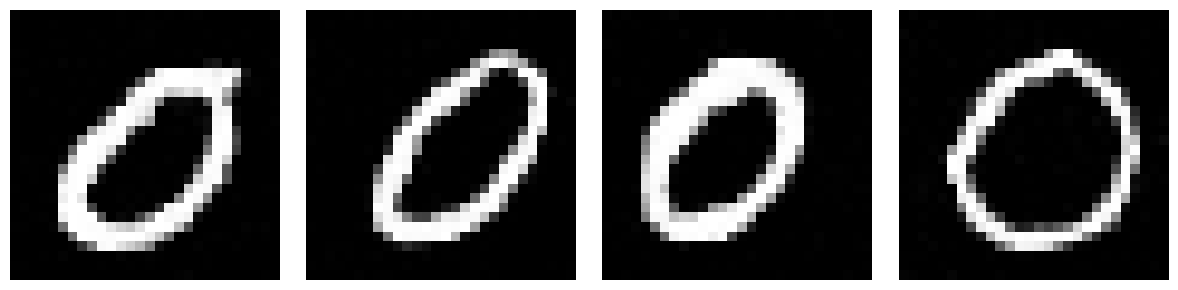

In [37]:
images_unet1 = generate_image(unet1,scheduler,n_images=4,ncol=4)

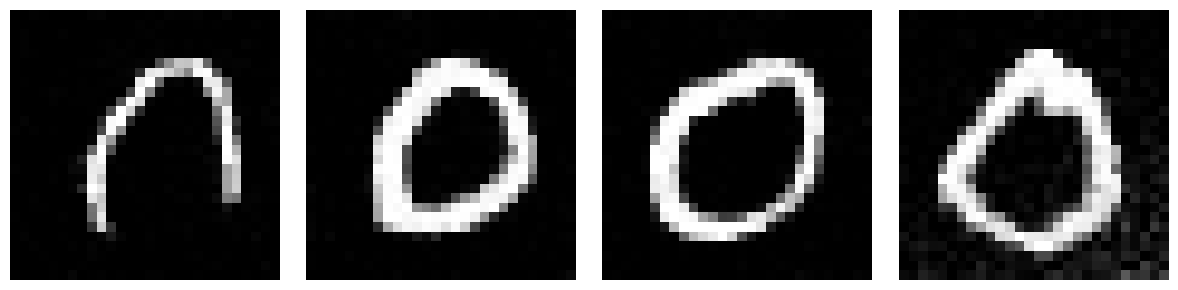

In [38]:
images_unet2 = generate_image(unet2,scheduler,n_images=4,ncol=4)

In [ ]:
images_unet_base = generate_image(unet_base,scheduler,n_images=4,ncol=4)

Next Steps:

time embedding

use cosine based variance schedule (nochol & dhariwal)

conditioning on input numbers
